In [1]:
# Google Colab에서 Car Damage Detection with YOLOv8m
# GPU 런타임 사용 권장: 런타임 > 런타임 유형 변경 > T4 GPU

# ==========================================
# 1. 환경 설정 및 패키지 설치
# ==========================================

!pip install ultralytics -q
!pip install roboflow -q

import os
import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import yaml
import shutil
import json
from sklearn.model_selection import train_test_split
from google.colab import drive, files
from IPython.display import display, Image as IPImage
import zipfile
from collections import defaultdict

# GPU 확인
!nvidia-smi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 118.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Sat Jan  3 12:19:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----

In [2]:
# ==========================================
# 2. Google Drive 마운트 (선택사항)
# ==========================================

# 데이터셋이 구글 드라이브에 있는 경우
drive.mount('/content/drive')

Mounted at /content/drive



🔧 YOLO 데이터셋 생성 시작

🔍 데이터 경로 확인:
  소스 경로: /content/drive/MyDrive/(share)2026_ImageDetectionStudy_No_resizing/damaged
  이미지 경로: /content/drive/MyDrive/(share)2026_ImageDetectionStudy_No_resizing/damaged/images (존재: True)
  라벨 경로: /content/drive/MyDrive/(share)2026_ImageDetectionStudy_No_resizing/damaged/labels (존재: True)
  JSON 파일: 1200개
  이미지 파일: 1200개

📄 총 1200개의 JSON 파일 발견
✂️  Train: 960개, Val: 240개로 분할

📦 Train 데이터 처리 중...
  100개 파일 처리 완료...
  200개 파일 처리 완료...
  300개 파일 처리 완료...
  400개 파일 처리 완료...
  500개 파일 처리 완료...
  600개 파일 처리 완료...
  700개 파일 처리 완료...
  800개 파일 처리 완료...
  900개 파일 처리 완료...
  ✓ 총 960개 파일 처리 완료
📦 Validation 데이터 처리 중...
  100개 파일 처리 완료...
  200개 파일 처리 완료...
  ✓ 총 240개 파일 처리 완료

📊 데이터셋 통계

[TRAIN]
  Breakage            :   421개 (13.73%)
  Crushed             :   248개 ( 8.09%)
  Scratched           :  1969개 (64.20%)
  Separated           :   429개 (13.99%)
  총계                  :  3067개

[VAL]
  Breakage            :   108개 (14.77%)
  Crushed             :    64개 ( 8.76%

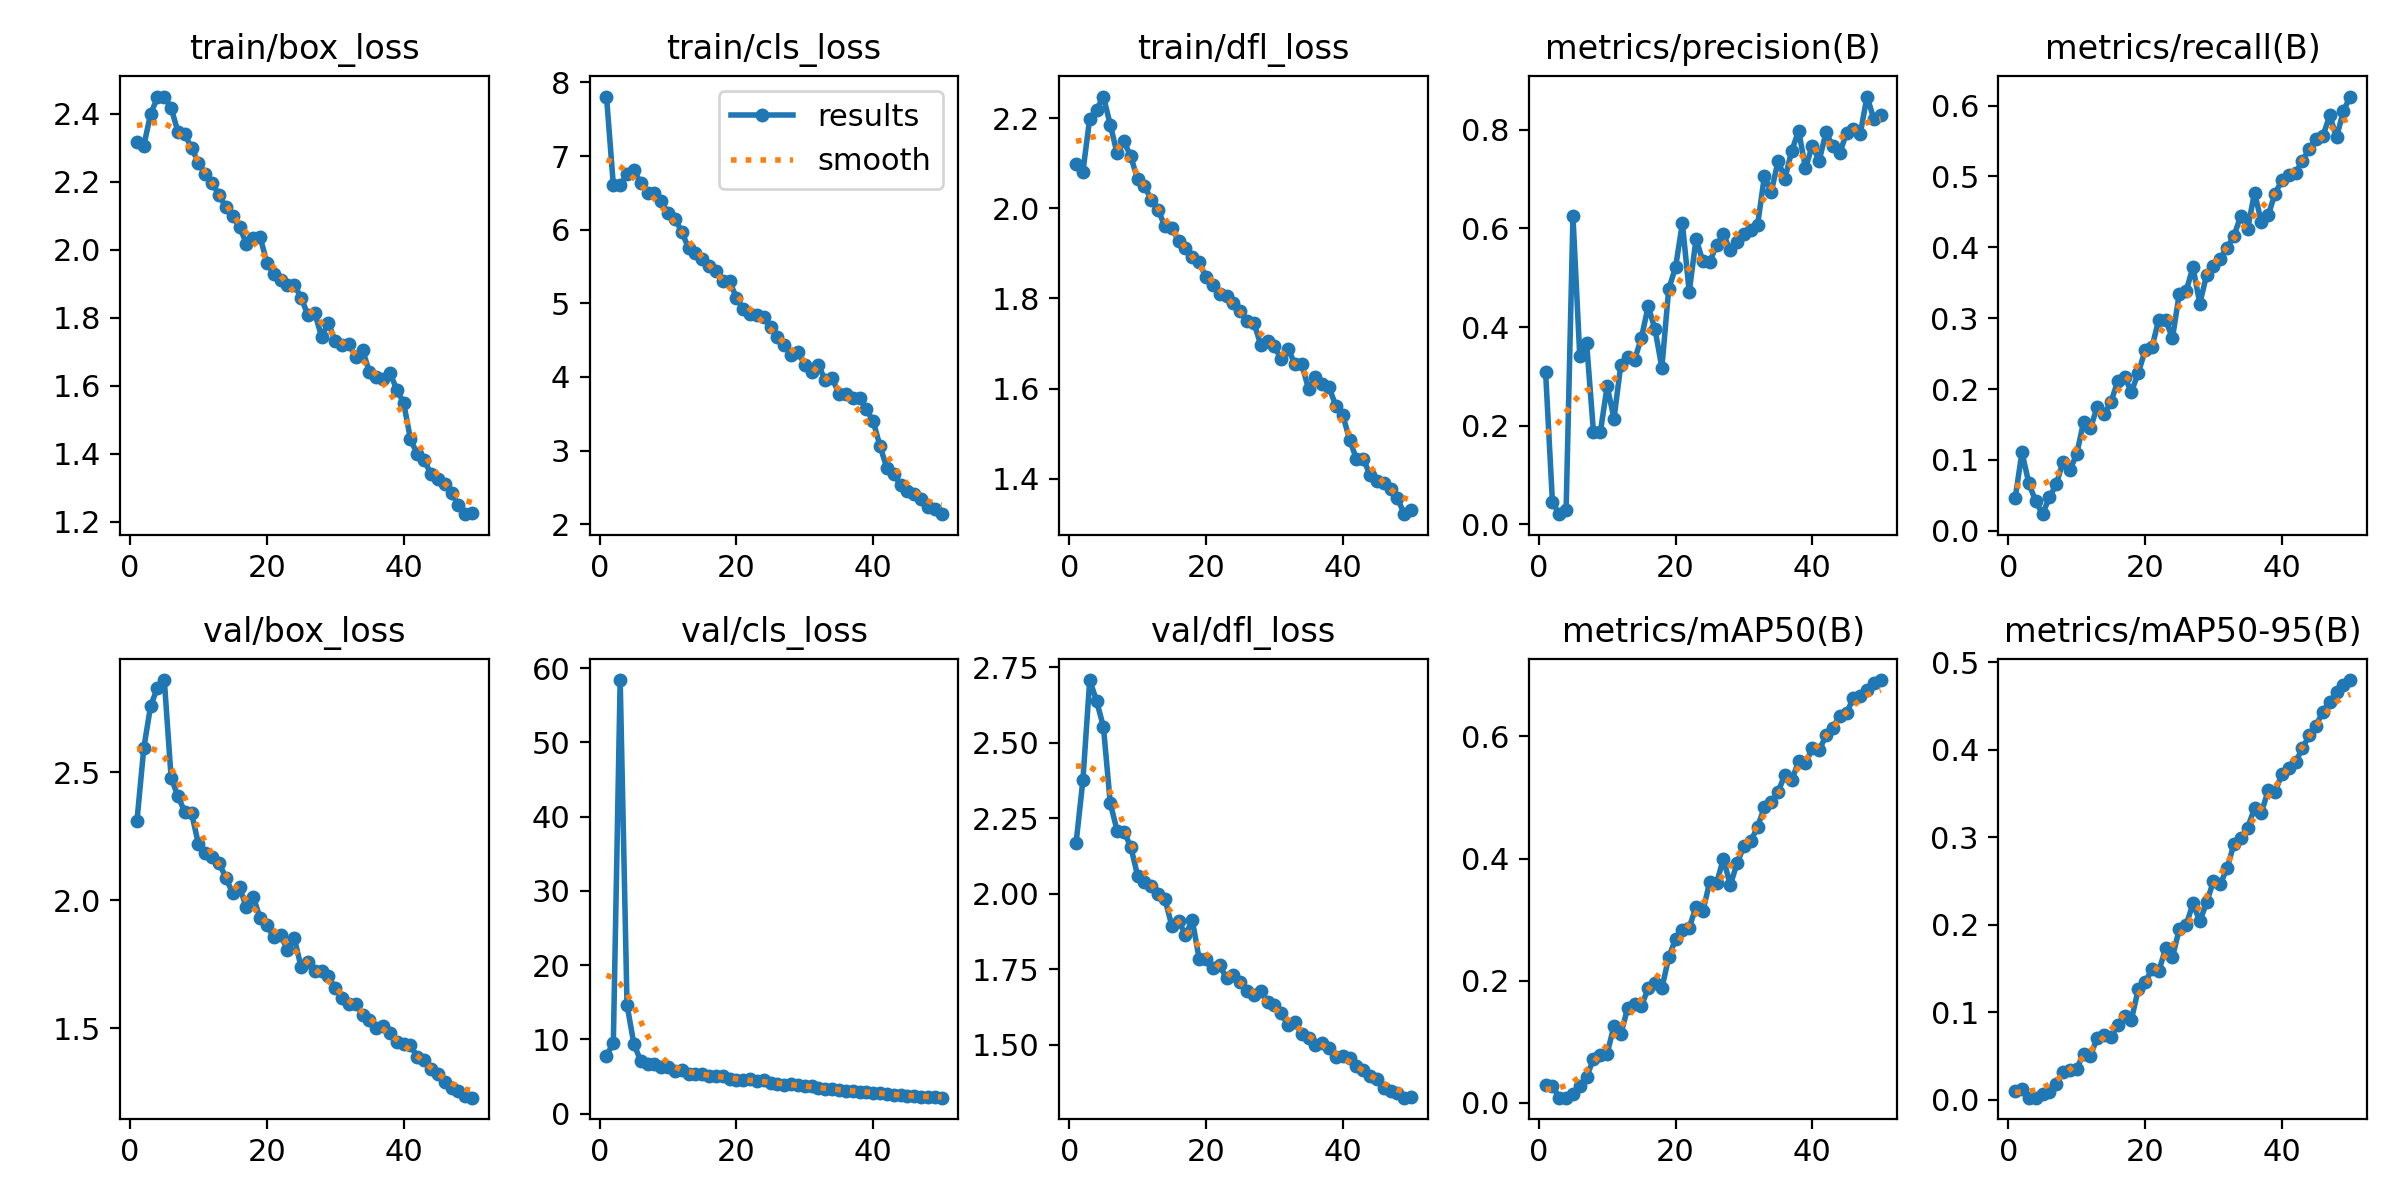


📊 혼동 행렬 (Confusion Matrix)
──────────────────────────────────────────────────────────────────────


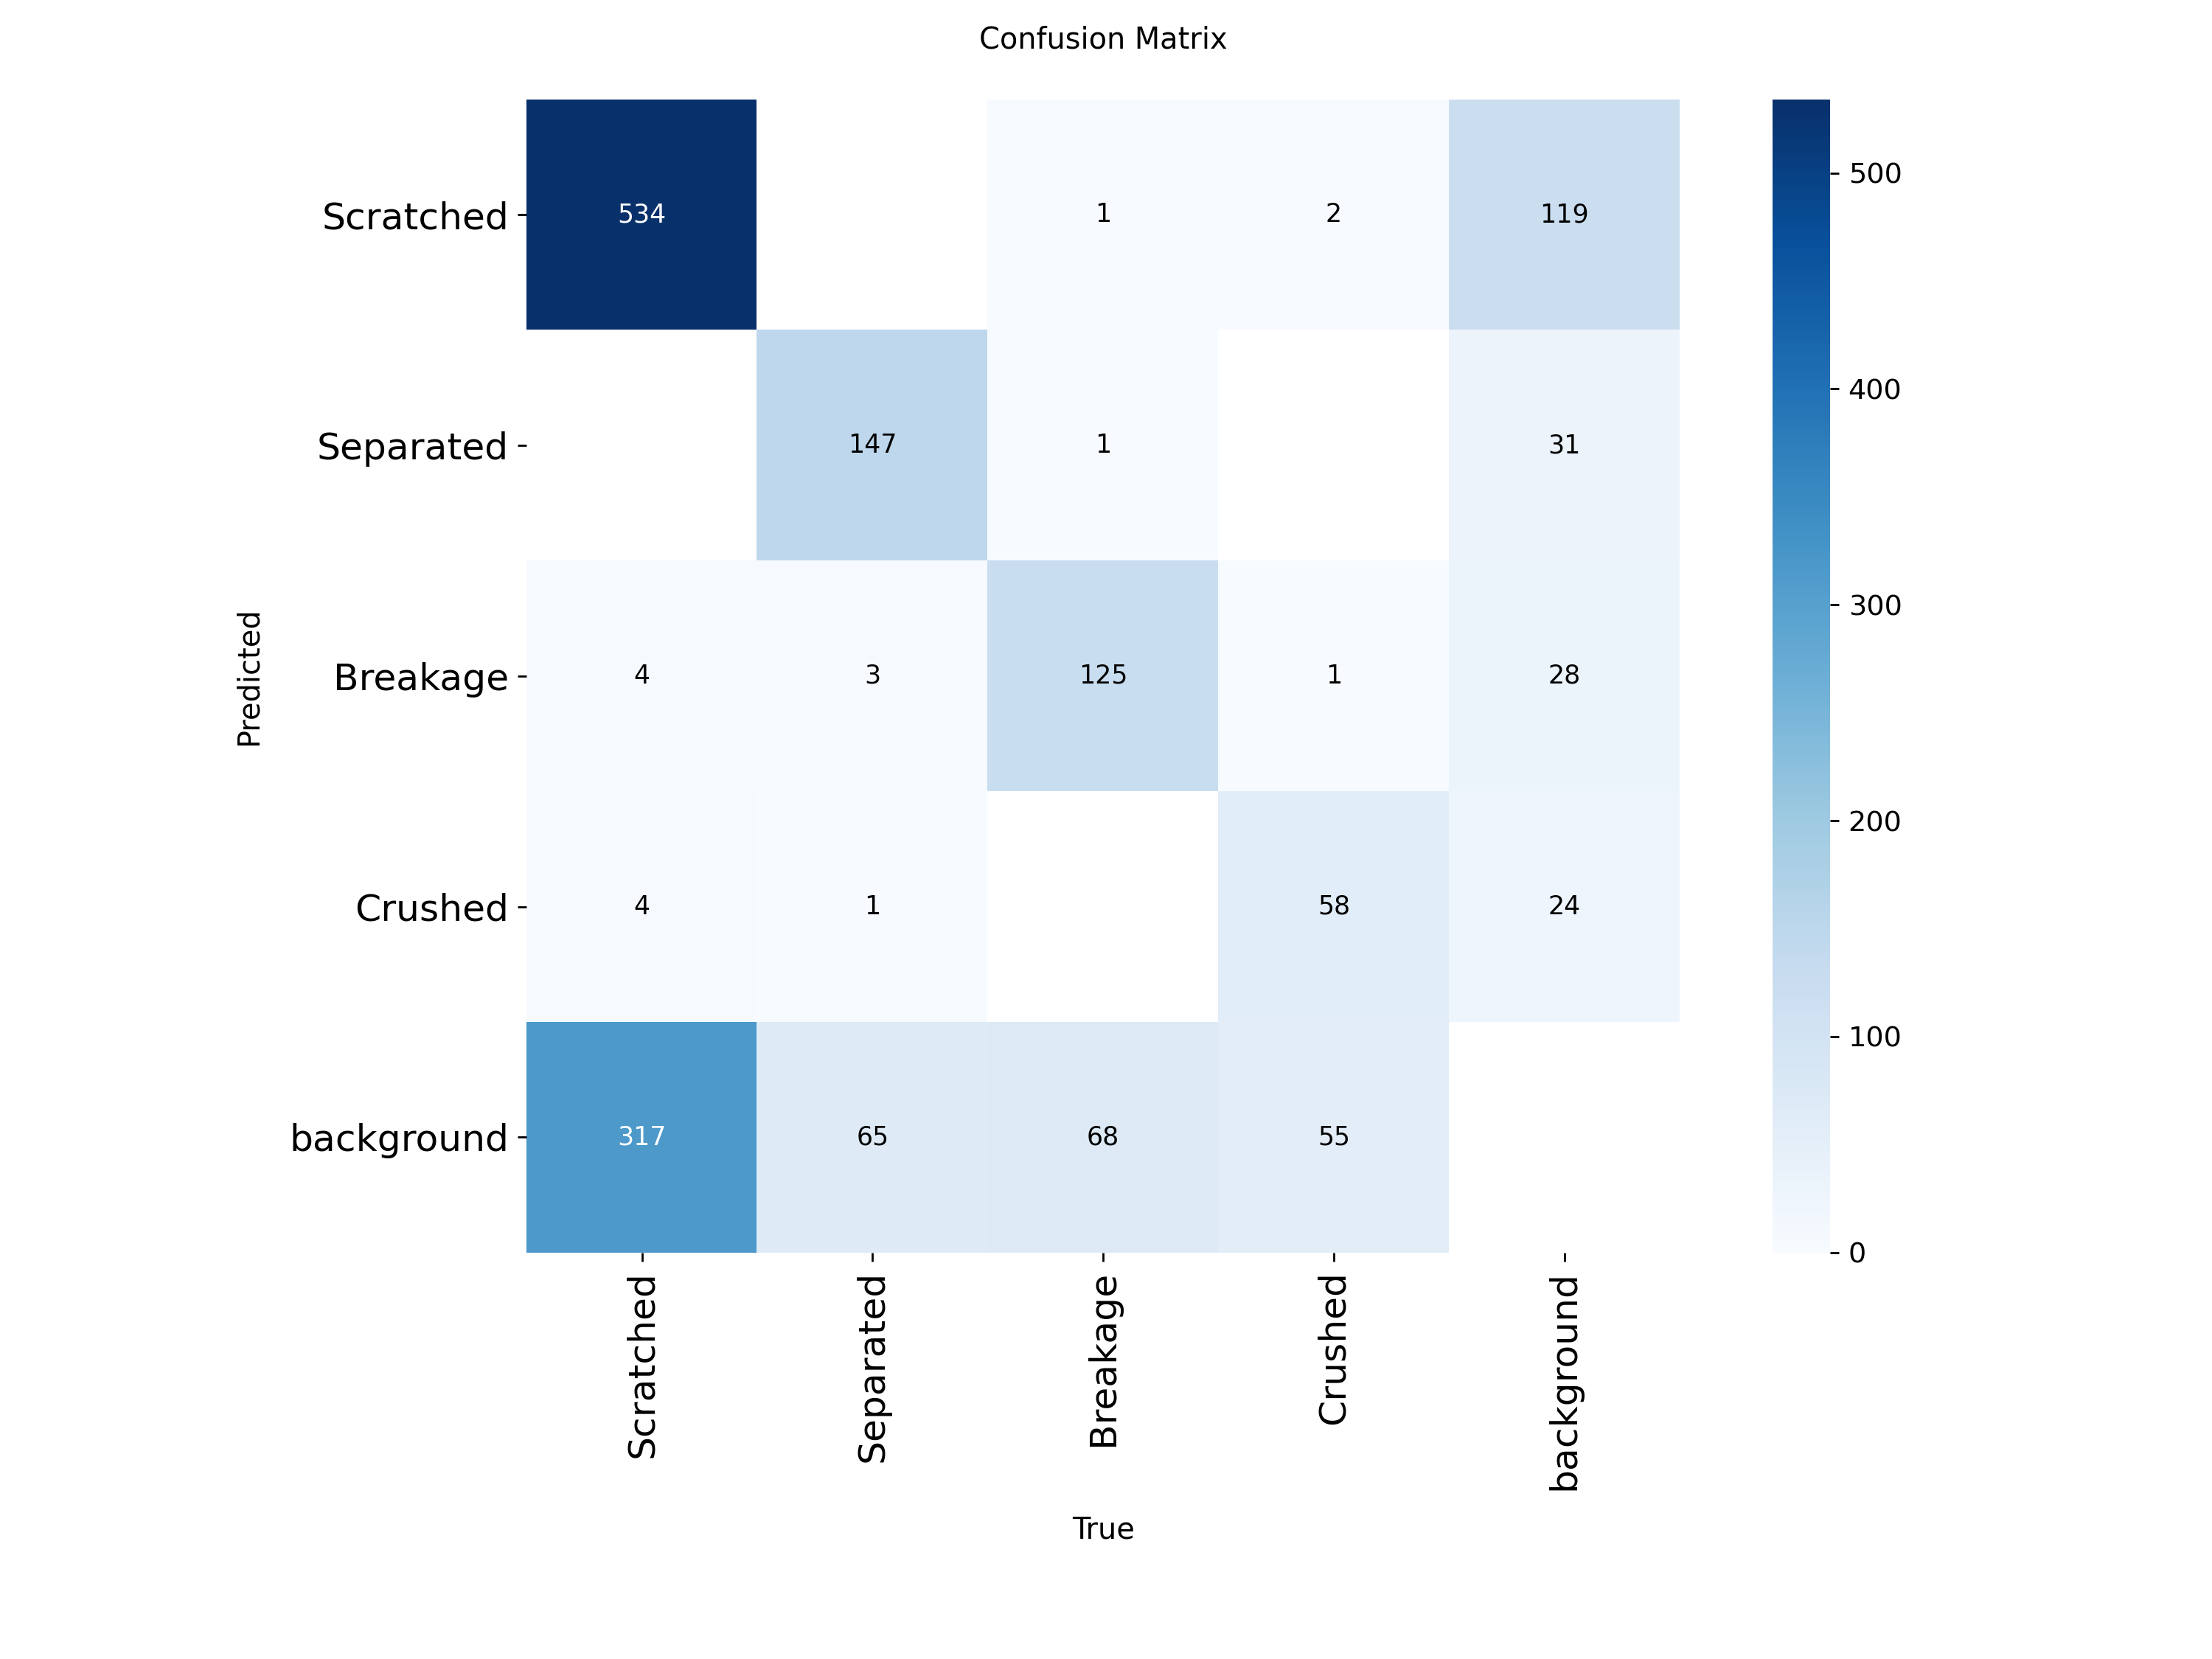


📊 정규화된 혼동 행렬
──────────────────────────────────────────────────────────────────────


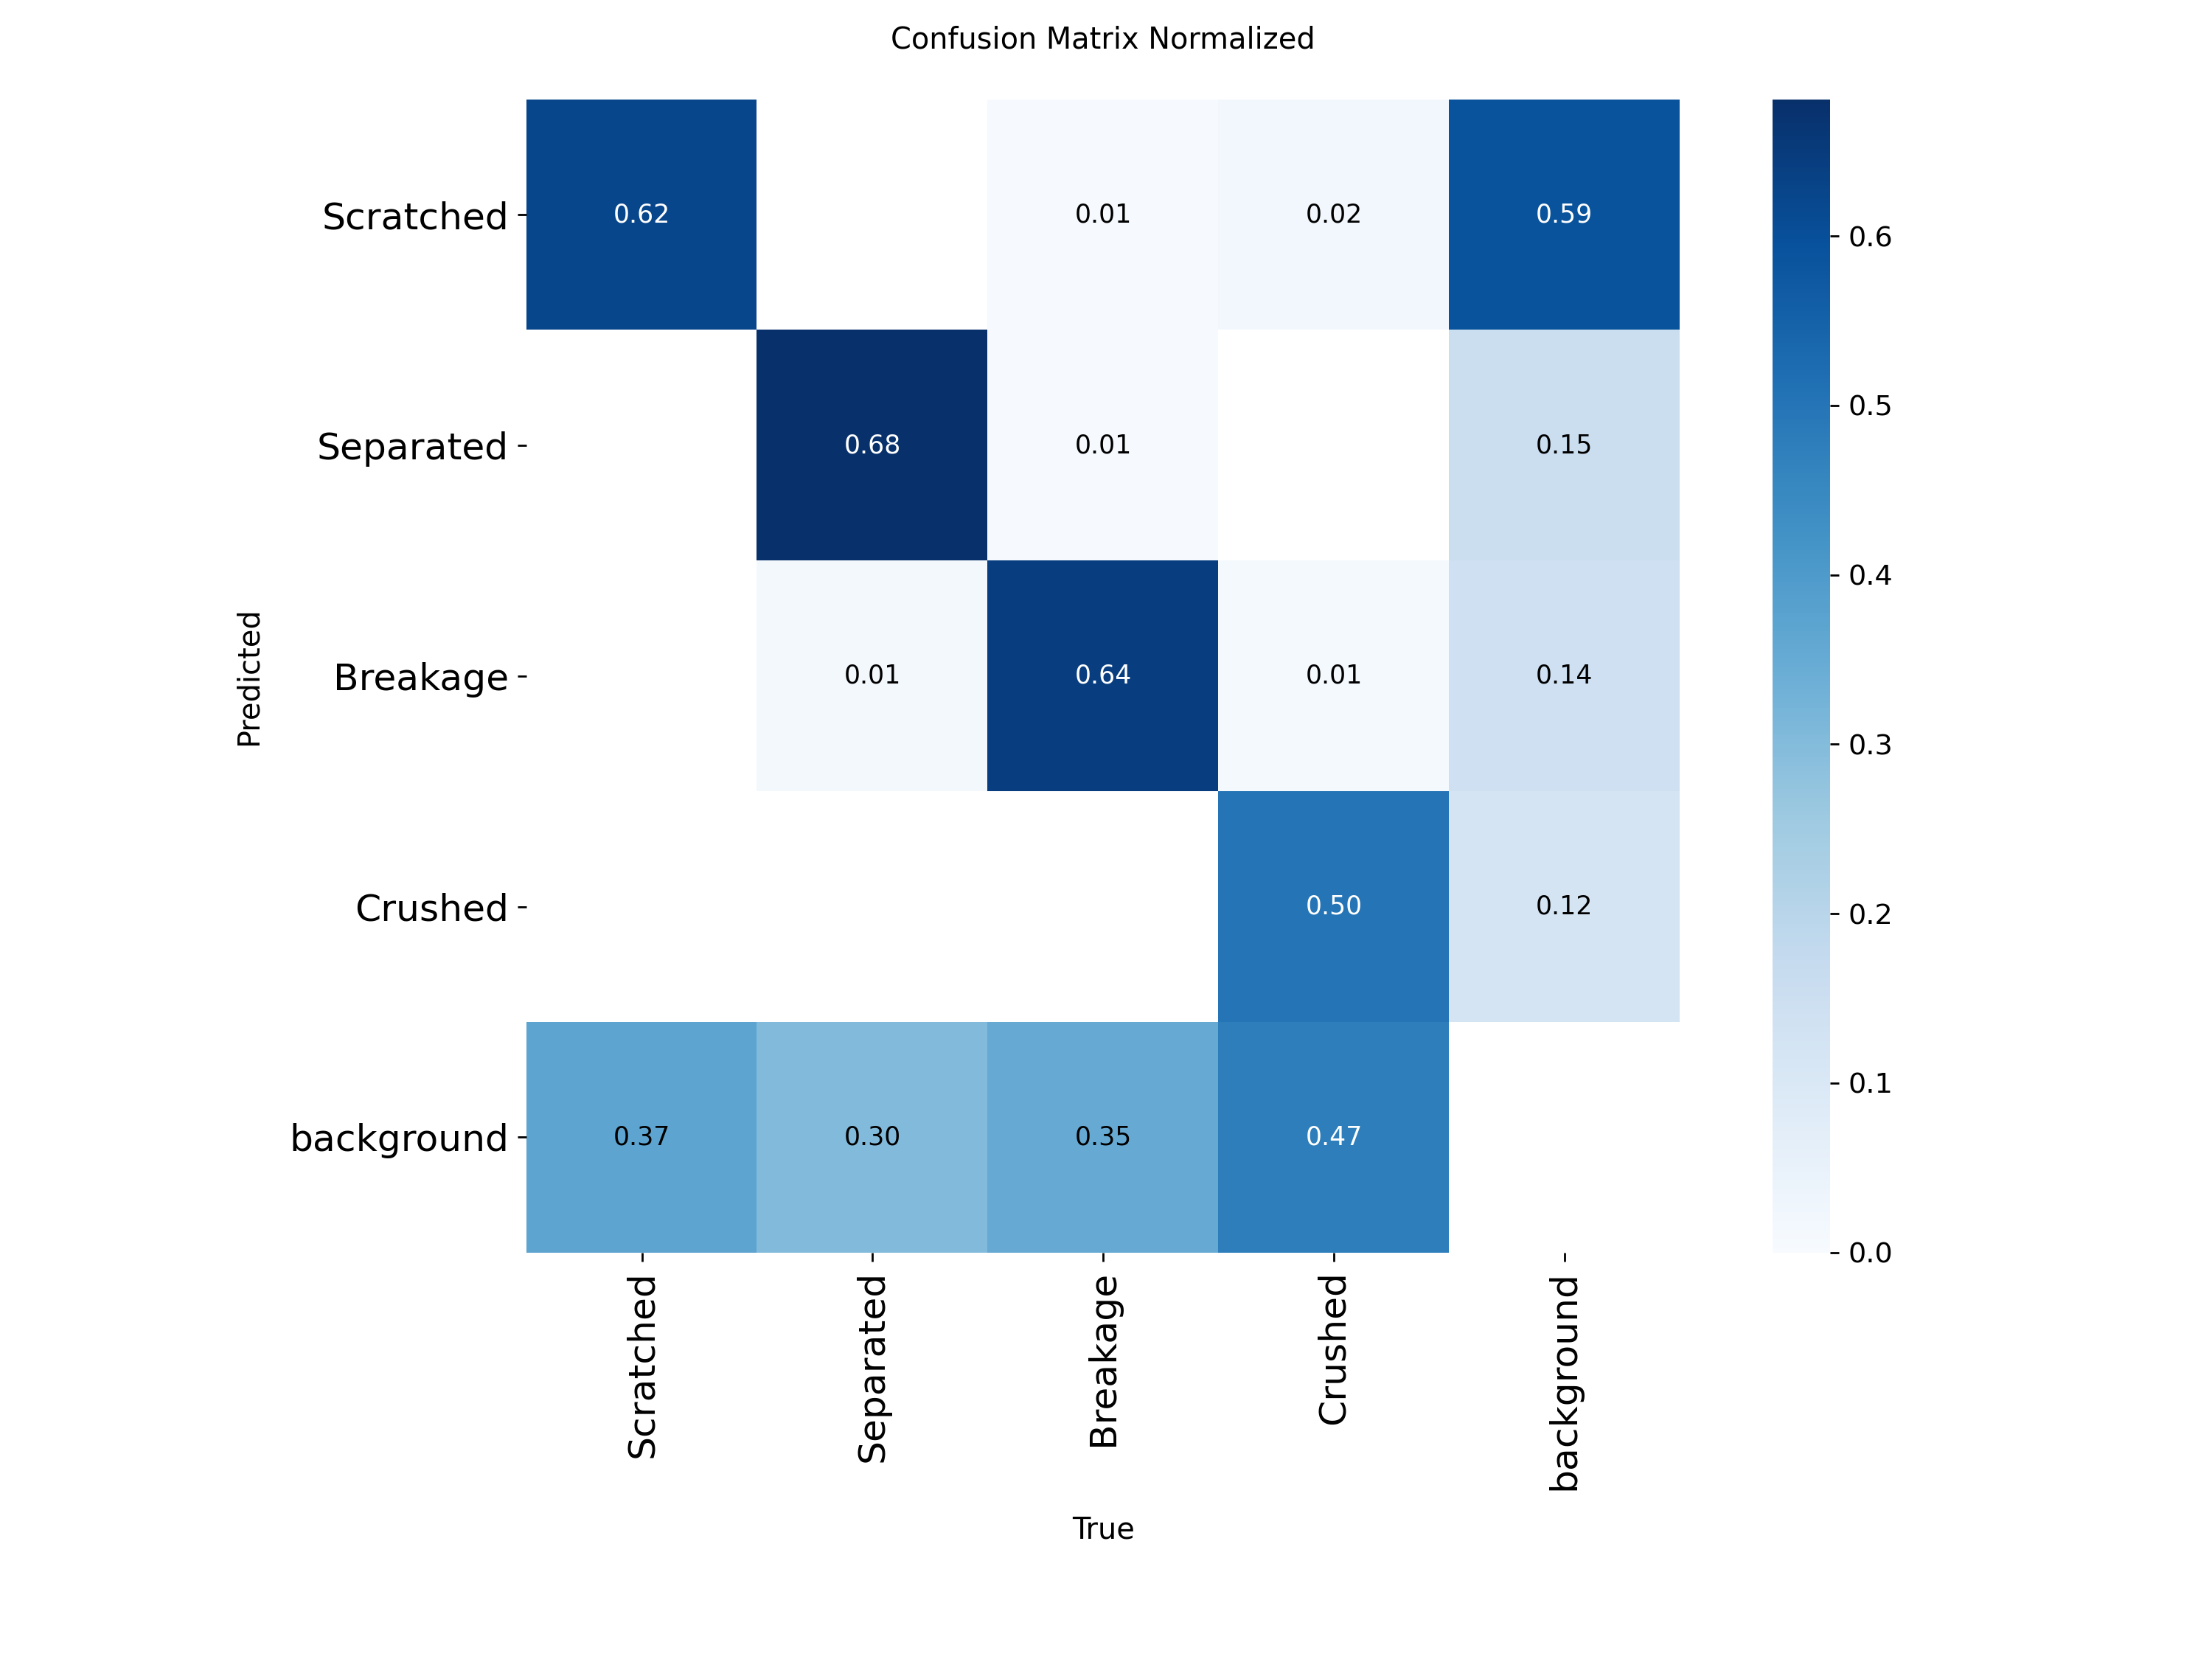


✅ 3개의 시각화 파일 표시 완료

📊 모델 성능 요약
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3685.0±958.3 MB/s, size: 741.8 KB)
val: Scanning /content/damage_dataset/val/labels.cache... 435 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 435/435 870.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.2it/s 12.6s
                   all        435       1386      0.811      0.591      0.677      0.477
Speed: 2.2ms preprocess, 16.6ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val

[전체 성능]
  mAP50      : 0.6773
  mAP50-95   : 0.4769
  Precision  : 0.8107
  Recall     : 0.5913

[클래스별 성능]
Class              mAP50   mAP50-95  Precision   Recall
──────────────────────────────────────────────────────────────────────
Scr

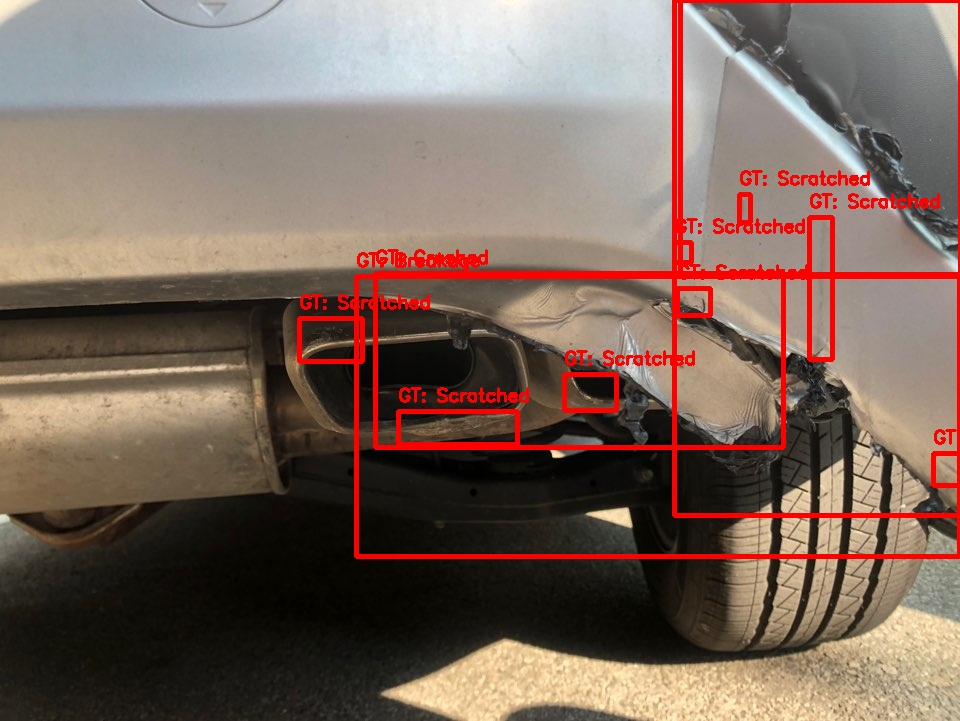


[2] GT: 9개, Pred: 1개, 놓침: 8개
──────────────────────────────────────────────────────────────────────


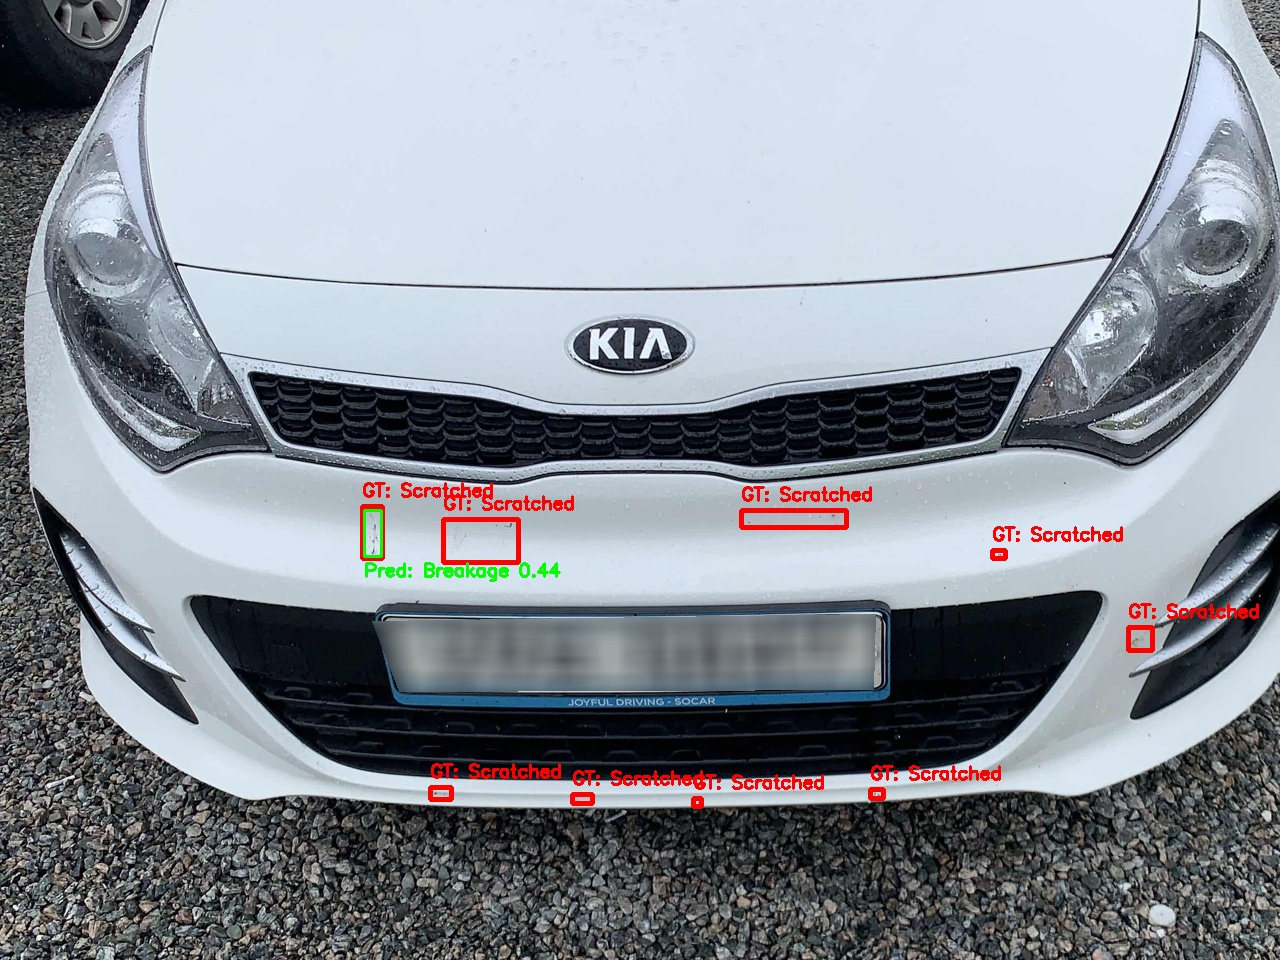


[3] GT: 10개, Pred: 3개, 놓침: 7개
──────────────────────────────────────────────────────────────────────


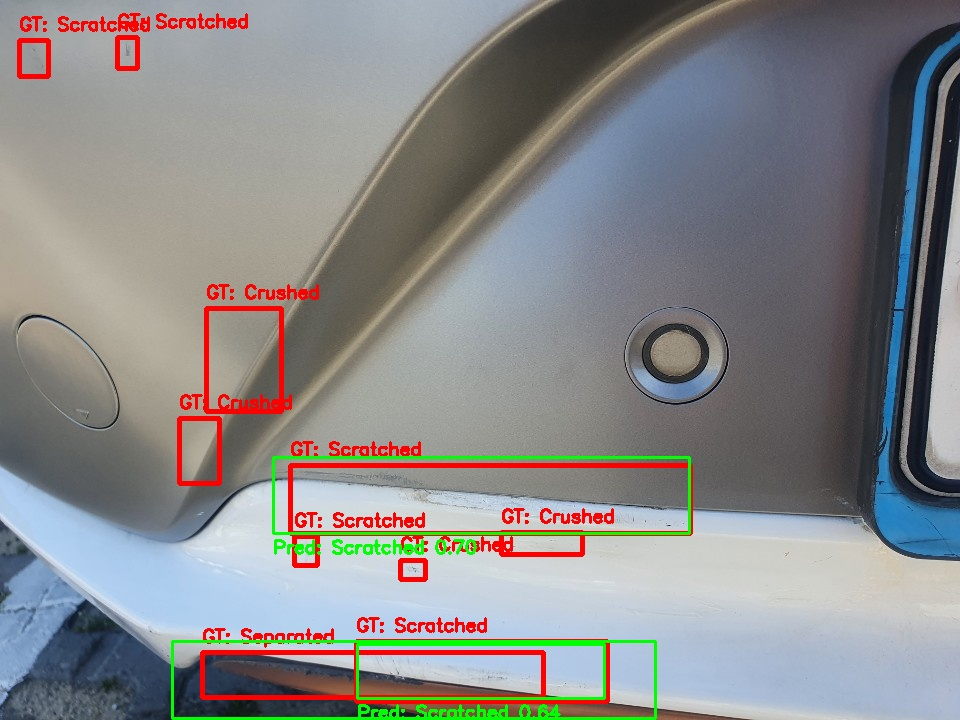


[4] GT: 9개, Pred: 2개, 놓침: 7개
──────────────────────────────────────────────────────────────────────


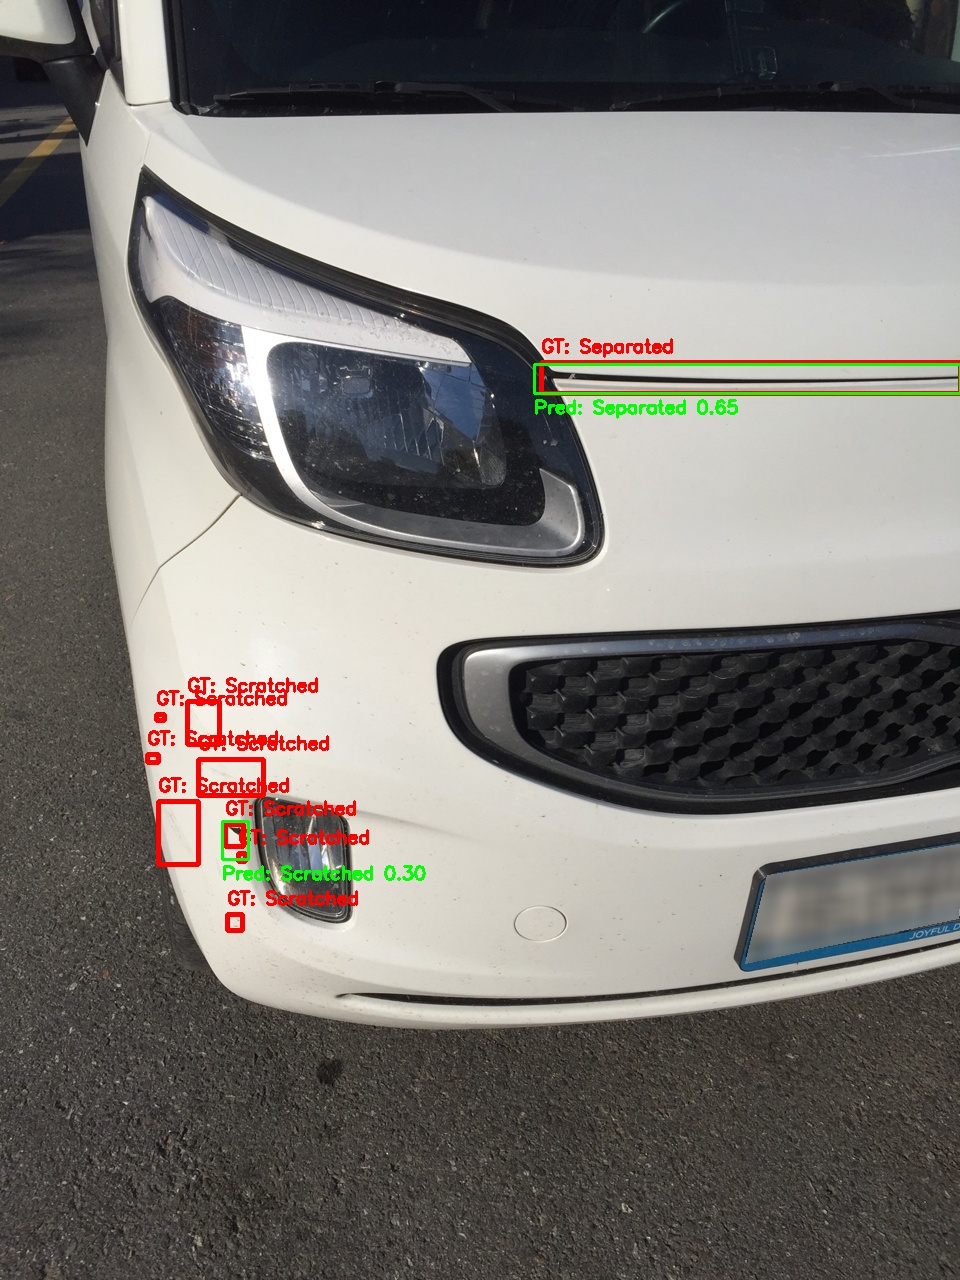


[5] GT: 8개, Pred: 1개, 놓침: 7개
──────────────────────────────────────────────────────────────────────


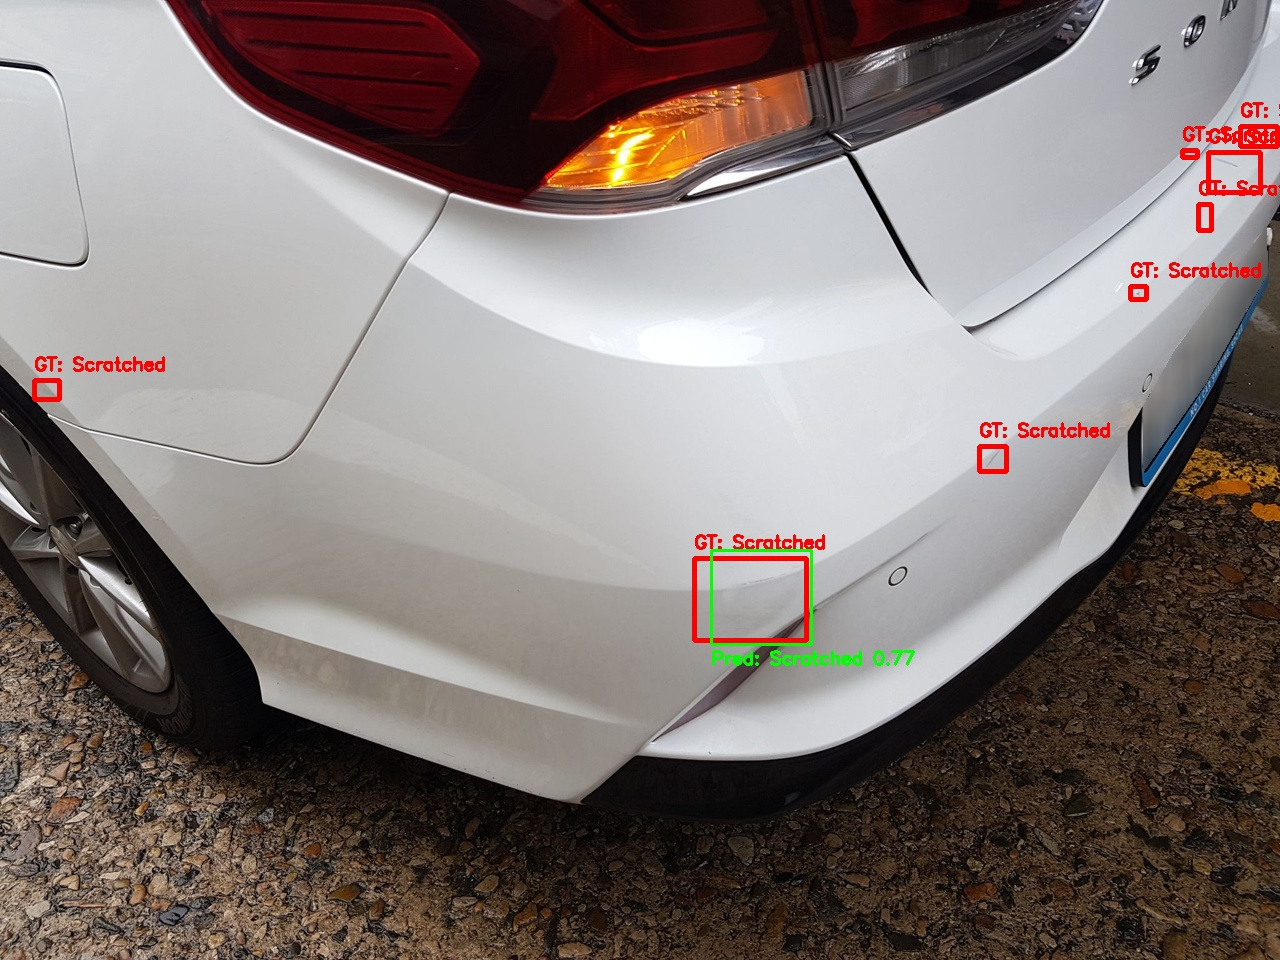


🎉 전체 파이프라인 완료!


In [4]:
import os
import json
import shutil
from pathlib import Path
from collections import defaultdict
import random
from ultralytics import YOLO
import yaml

class DamageDetectionPipeline:
    """
    자동차 손상 탐지 모델 학습 파이프라인
    """

    def __init__(self, source_path, output_path='./damage_dataset'):
        self.source_path = Path(source_path)
        self.output_path = Path(output_path)

        # 소스 데이터 구조 파악
        self.images_path = self.source_path / 'images'
        self.labels_path = self.source_path / 'labels'

        # 손상 클래스 매핑
        self.damage_classes = {
            'Scratched': 0,
            'Separated': 1,
            'Breakage': 2,
            'Crushed': 3
        }

    def create_yolo_dataset(self, train_ratio=0.8, val_ratio=0.2):
        """
        YOLO 형식의 데이터셋 생성 (train/val split)
        """
        print("\n" + "="*70)
        print("🔧 YOLO 데이터셋 생성 시작")
        print("="*70)

        # 출력 디렉토리 구조 생성
        for split in ['train', 'val']:
            for subdir in ['images', 'labels']:
                (self.output_path / split / subdir).mkdir(parents=True, exist_ok=True)

        # 경로 확인 및 디버깅
        print(f"\n🔍 데이터 경로 확인:")
        print(f"  소스 경로: {self.source_path}")
        print(f"  이미지 경로: {self.images_path} (존재: {self.images_path.exists()})")
        print(f"  라벨 경로: {self.labels_path} (존재: {self.labels_path.exists()})")

        if not self.images_path.exists() or not self.labels_path.exists():
            print(f"  ❌ 이미지 또는 라벨 폴더가 존재하지 않습니다!")
            return None

        # 파일 개수 확인
        json_count = len(list(self.labels_path.glob('*.json')))
        img_count = len(list(self.images_path.glob('*.jpg'))) + len(list(self.images_path.glob('*.png')))
        print(f"  JSON 파일: {json_count}개")
        print(f"  이미지 파일: {img_count}개")

        # JSON 파일 수집
        json_files = list(self.labels_path.glob('*.json'))
        print(f"\n📄 총 {len(json_files)}개의 JSON 파일 발견")

        if len(json_files) == 0:
            print("\n❌ JSON 파일을 찾을 수 없습니다!")
            print("💡 해결 방법:")
            print("  1. 경로를 확인하세요")
            print("  2. JSON 파일이 하위 폴더에 있다면 경로를 수정하세요")
            print(f"  3. 현재 경로: {self.source_path.absolute()}")
            return None

        # 데이터 분할
        random.shuffle(json_files)
        split_idx = int(len(json_files) * train_ratio)
        train_files = json_files[:split_idx]
        val_files = json_files[split_idx:]

        print(f"✂️  Train: {len(train_files)}개, Val: {len(val_files)}개로 분할")

        # 통계 수집
        stats = {'train': defaultdict(int), 'val': defaultdict(int)}

        # Train 데이터 처리
        print("\n📦 Train 데이터 처리 중...")
        self._process_files(train_files, 'train', stats['train'])

        # Validation 데이터 처리
        print("📦 Validation 데이터 처리 중...")
        self._process_files(val_files, 'val', stats['val'])

        # 통계 출력
        self._print_statistics(stats)

        # data.yaml 생성
        self._create_yaml_config()

        print("\n✅ 데이터셋 생성 완료!")
        print(f"📁 저장 위치: {self.output_path.absolute()}")

        return stats

    def _process_files(self, json_files, split, stats):
        """
        JSON 파일들을 처리하여 YOLO 형식으로 변환
        """
        processed = 0
        skipped = 0

        for json_file in json_files:
            try:
                with open(json_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                # 이미지 파일 찾기 (images 폴더에서)
                # 'filename' -> 'file_name'으로 수정
                img_filename = data['images']['file_name']
                img_path = self.images_path / img_filename

                # 이미지 파일이 없으면 같은 이름의 다른 확장자 찾기
                if not img_path.exists():
                    base_name = img_filename.rsplit('.', 1)[0]
                    found = False
                    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                        alt_path = self.images_path / f"{base_name}{ext}"
                        if alt_path.exists():
                            img_path = alt_path
                            img_filename = alt_path.name
                            found = True
                            break

                    if not found:
                        if skipped < 5:  # 처음 5개만 출력
                            print(f"  ⚠️  이미지 없음: {img_filename}")
                        skipped += 1
                        continue

                # 이미지 복사
                dest_img = self.output_path / split / 'images' / img_filename
                shutil.copy2(img_path, dest_img)

                # YOLO 라벨 생성
                img_width = data['images']['width']
                img_height = data['images']['height']

                label_lines = []
                for ann in data['annotations']:
                    damage_type = ann['damage']
                    if damage_type not in self.damage_classes:
                        continue

                    class_id = self.damage_classes[damage_type]
                    stats[damage_type] += 1

                    # Bbox를 YOLO 형식으로 변환 (normalized)
                    bbox = ann['bbox']
                    x_center = (bbox[0] + bbox[2] / 2) / img_width
                    y_center = (bbox[1] + bbox[3] / 2) / img_height
                    width = bbox[2] / img_width
                    height = bbox[3] / img_height

                    # 값 검증 (0~1 범위)
                    x_center = max(0, min(1, x_center))
                    y_center = max(0, min(1, y_center))
                    width = max(0, min(1, width))
                    height = max(0, min(1, height))

                    label_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

                # 라벨 파일 저장
                if label_lines:
                    label_path = self.output_path / split / 'labels' / f"{img_filename.rsplit('.', 1)[0]}.txt"
                    with open(label_path, 'w') as f:
                        f.write('\n'.join(label_lines))

                    processed += 1

                    if processed % 100 == 0:
                        print(f"  {processed}개 파일 처리 완료...")

            except Exception as e:
                if skipped < 5:
                    print(f"  ⚠️  {json_file.name} 처리 실패: {str(e)}")
                skipped += 1
                continue

        print(f"  ✓ 총 {processed}개 파일 처리 완료")
        if skipped > 0:
            print(f"  ⚠️  {skipped}개 파일 건너뜀 (이미지 없음 또는 오류)")

    def _print_statistics(self, stats):
        """
        데이터셋 통계 출력
        """
        print("\n" + "="*70)
        print("📊 데이터셋 통계")
        print("="*70)

        for split in ['train', 'val']:
            print(f"\n[{split.upper()}]")
            total = sum(stats[split].values())
            for damage_type, count in sorted(stats[split].items()):
                percentage = (count / total * 100) if total > 0 else 0
                print(f"  {damage_type:20s}: {count:5d}개 ({percentage:5.2f}%)")
            print(f"  {'총계':20s}: {total:5d}개")

    def _create_yaml_config(self):
        """
        YOLO 학습을 위한 data.yaml 파일 생성
        """
        config = {
            'train': str((self.output_path / 'train' / 'images').absolute()),
            'val': str((self.output_path / 'val' / 'images').absolute()),
            'nc': len(self.damage_classes),
            'names': list(self.damage_classes.keys())
        }

        yaml_path = self.output_path / 'data.yaml'
        with open(yaml_path, 'w') as f:
            yaml.dump(config, f, default_flow_style=False)

        print(f"\n📝 data.yaml 생성: {yaml_path}")
        print(f"  Train: {config['train']}")
        print(f"  Val: {config['val']}")

    def train_model(self, model_size='yolov8m.pt', epochs=100, imgsz=640, batch=16,
                    conf_thres=0.001, iou_thres=0.6):
        """
        YOLOv8 모델 학습
        """
        print("\n" + "="*70)
        print("🚀 YOLOv8 모델 학습 시작")
        print("="*70)

        # 모델 초기화
        model = YOLO(model_size)

        # 학습 설정
        print(f"\n⚙️  학습 설정:")
        print(f"  - 모델: {model_size}")
        print(f"  - Epochs: {epochs}")
        print(f"  - Image Size: {imgsz}")
        print(f"  - Batch Size: {batch}")
        print(f"  - Confidence Threshold: {conf_thres}")
        print(f"  - IoU Threshold: {iou_thres}")

        # 학습 시작
        results = model.train(
            data=str(self.output_path / 'data.yaml'),
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            patience=30,  # 30 에폭으로 증가
            save=True,
            device=0,
            workers=8,
            project='damage_detection',
            name='exp',
            exist_ok=True,
            pretrained=True,
            optimizer='auto',
            verbose=True,
            seed=42,
            deterministic=True,
            single_cls=False,
            rect=False,
            cos_lr=False,
            close_mosaic=10,
            resume=False,
            amp=True,
            fraction=1.0,
            profile=False,
            freeze=None,
            # 학습률 조정 (더 천천히 학습)
            lr0=0.005,  # 0.01 -> 0.005
            lrf=0.005,  # 0.01 -> 0.005
            momentum=0.937,
            weight_decay=0.0005,
            warmup_epochs=5.0,  # 3.0 -> 5.0 (더 긴 워밍업)
            warmup_momentum=0.8,
            warmup_bias_lr=0.1,
            # Loss 가중치 (객체 탐지 향상)
            box=7.5,
            cls=1.0,  # 0.5 -> 1.0 (클래스 분류 강화)
            dfl=1.5,
            # Augmentation (데이터 증강 강화)
            hsv_h=0.015,
            hsv_s=0.7,
            hsv_v=0.4,
            degrees=0.0,
            translate=0.1,
            scale=0.5,
            shear=0.0,
            perspective=0.0,
            flipud=0.0,
            fliplr=0.5,
            mosaic=1.0,
            mixup=0.15,  # 0.0 -> 0.15 (mixup 추가)
            copy_paste=0.0,
            # Validation 설정
            conf=conf_thres,
            iou=iou_thres
        )

        print("\n✅ 학습 완료!")
        print(f"📁 결과 저장 위치: damage_detection/exp")

        return results

    def evaluate_detection_comprehensive(self, model_path='damage_detection/exp/weights/best.pt',
                                        conf_threshold=0.25, iou_threshold=0.5):
        """
        종합 탐지 성능 평가: 이미지 레벨과 객체 레벨 모두 평가
        """
        print("\n" + "="*70)
        print("📊 종합 탐지 성능 평가")
        print("="*70)
        print(f"신뢰도 임계값: {conf_threshold}")
        print(f"IoU 임계값: {iou_threshold}")

        # 모델 로드
        model = YOLO(model_path)

        # Validation 데이터 경로
        val_images_path = self.output_path / 'val' / 'images'
        val_labels_path = self.output_path / 'val' / 'labels'

        image_files = list(val_images_path.glob('*.jpg')) + list(val_images_path.glob('*.png'))

        print(f"\n🔍 {len(image_files)}개 이미지 분석 중...\n")

        # === 이미지 레벨 통계 ===
        img_total = 0
        img_with_damage = 0
        img_detected = 0  # 1개라도 찾은 이미지
        img_missed = 0    # 완전히 놓친 이미지

        # === 객체 레벨 통계 ===
        obj_total_gt = 0      # 실제 손상 총 개수
        obj_total_pred = 0    # 예측된 손상 총 개수
        obj_correct = 0       # 정확히 매칭된 손상 개수 (IoU > threshold)
        obj_missed = 0        # 놓친 손상 개수
        obj_false_positive = 0 # 과탐지 개수

        # 클래스별 통계
        class_stats = {name: {'gt': 0, 'correct': 0, 'missed': 0}
                      for name in self.damage_classes.keys()}

        missed_images = []

        for img_path in image_files:
            img_total += 1

            # Ground Truth 로드
            label_path = val_labels_path / f"{img_path.stem}.txt"
            gt_boxes = []

            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        if line.strip():
                            parts = line.strip().split()
                            class_id = int(parts[0])
                            bbox = list(map(float, parts[1:]))
                            gt_boxes.append({'class': class_id, 'bbox': bbox})

            if len(gt_boxes) == 0:
                continue

            img_with_damage += 1
            obj_total_gt += len(gt_boxes)

            # 클래스별 GT 카운트
            for gt in gt_boxes:
                class_name = list(self.damage_classes.keys())[gt['class']]
                class_stats[class_name]['gt'] += 1

            # 모델 예측
            results = model.predict(str(img_path), conf=conf_threshold, verbose=False)
            pred_boxes = results[0].boxes

            # === 이미지 레벨 평가 ===
            if pred_boxes is not None and len(pred_boxes) > 0:
                img_detected += 1
            else:
                img_missed += 1
                missed_images.append({
                    'image': img_path.name,
                    'gt_count': len(gt_boxes)
                })

            # === 객체 레벨 평가 ===
            if pred_boxes is None or len(pred_boxes) == 0:
                obj_missed += len(gt_boxes)
                for gt in gt_boxes:
                    class_name = list(self.damage_classes.keys())[gt['class']]
                    class_stats[class_name]['missed'] += 1
                continue

            obj_total_pred += len(pred_boxes)

            # IoU 계산하여 매칭
            matched_gt = set()
            matched_pred = set()

            for i, pred_box in enumerate(pred_boxes):
                pred_cls = int(pred_box.cls[0])
                pred_bbox_xyxy = pred_box.xyxy[0].cpu().numpy()

                # 이미지 크기
                img_h, img_w = results[0].orig_shape

                # Pred bbox를 normalized로 변환
                pred_x_center = ((pred_bbox_xyxy[0] + pred_bbox_xyxy[2]) / 2) / img_w
                pred_y_center = ((pred_bbox_xyxy[1] + pred_bbox_xyxy[3]) / 2) / img_h
                pred_width = (pred_bbox_xyxy[2] - pred_bbox_xyxy[0]) / img_w
                pred_height = (pred_bbox_xyxy[3] - pred_bbox_xyxy[1]) / img_h

                best_iou = 0
                best_gt_idx = -1

                for j, gt in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue

                    if gt['class'] != pred_cls:
                        continue

                    # GT bbox (normalized)
                    gt_bbox = gt['bbox']

                    # IoU 계산
                    iou = self._calculate_iou(
                        [pred_x_center, pred_y_center, pred_width, pred_height],
                        gt_bbox
                    )

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

                # 매칭 성공
                if best_iou >= iou_threshold:
                    matched_gt.add(best_gt_idx)
                    matched_pred.add(i)
                    obj_correct += 1
                    class_name = list(self.damage_classes.keys())[pred_cls]
                    class_stats[class_name]['correct'] += 1

            # 매칭 안 된 GT = 놓친 것
            for j, gt in enumerate(gt_boxes):
                if j not in matched_gt:
                    obj_missed += 1
                    class_name = list(self.damage_classes.keys())[gt['class']]
                    class_stats[class_name]['missed'] += 1

            # 매칭 안 된 Pred = 과탐지
            obj_false_positive += (len(pred_boxes) - len(matched_pred))

        # === 결과 계산 ===
        # 이미지 레벨
        img_detection_rate = (img_detected / img_with_damage * 100) if img_with_damage > 0 else 0
        img_miss_rate = (img_missed / img_with_damage * 100) if img_with_damage > 0 else 0

        # 객체 레벨
        obj_precision = (obj_correct / obj_total_pred * 100) if obj_total_pred > 0 else 0
        obj_recall = (obj_correct / obj_total_gt * 100) if obj_total_gt > 0 else 0
        obj_f1 = (2 * obj_precision * obj_recall / (obj_precision + obj_recall)) if (obj_precision + obj_recall) > 0 else 0

        # === 결과 출력 ===
        print("="*70)
        print("🎯 [1] 이미지 레벨 평가 (1개라도 찾으면 성공)")
        print("="*70)
        print(f"손상이 있는 이미지        : {img_with_damage}개")
        print(f"✅ 1개 이상 탐지 성공     : {img_detected}개 ({img_detection_rate:.1f}%)")
        print(f"❌ 완전히 놓침 (0개 탐지) : {img_missed}개 ({img_miss_rate:.1f}%)")

        print("\n" + "="*70)
        print("🎯 [2] 객체 레벨 평가 (각 손상을 정확히 찾았는지)")
        print("="*70)
        print(f"실제 손상 총 개수         : {obj_total_gt}개")
        print(f"예측된 손상 총 개수       : {obj_total_pred}개")
        print(f"")
        print(f"✅ 정확히 매칭된 손상     : {obj_correct}개")
        print(f"❌ 놓친 손상              : {obj_missed}개")
        print(f"⚠️  과탐지 (FP)           : {obj_false_positive}개")
        print(f"")
        print(f"📊 Precision              : {obj_precision:.1f}%")
        print(f"📊 Recall                 : {obj_recall:.1f}%")
        print(f"📊 F1 Score               : {obj_f1:.1f}%")

        # 클래스별 상세 통계
        print("\n" + "="*70)
        print("📋 클래스별 상세 통계")
        print("="*70)
        print(f"{'클래스':<15} {'실제(GT)':>10} {'정확히 찾음':>12} {'놓침':>8} {'Recall':>10}")
        print("─" * 70)
        for class_name, stats in class_stats.items():
            recall = (stats['correct'] / stats['gt'] * 100) if stats['gt'] > 0 else 0
            print(f"{class_name:<15} {stats['gt']:>10}개 {stats['correct']:>12}개 "
                  f"{stats['missed']:>8}개 {recall:>9.1f}%")

        # 비교 분석
        print("\n" + "="*70)
        print("💡 두 평가 방식 비교")
        print("="*70)
        print(f"• [이미지 레벨] 손상 '감지' 성공률    : {img_detection_rate:.1f}%")
        print(f"  → 손상이 있는 차량인지 알아챘는가?")
        print(f"")
        print(f"• [객체 레벨] 손상 '인식' 정확도 (Recall): {obj_recall:.1f}%")
        print(f"  → 각 손상을 정확히 찾아냈는가?")
        print(f"")

        gap = img_detection_rate - obj_recall
        if gap > 10:
            print(f"⚠️  차이: {gap:.1f}%p")
            print(f"   → 손상이 있다는 건 알지만, 일부 손상은 정확히 찾지 못함")

        # 완전히 놓친 이미지 목록
        if len(missed_images) > 0:
            print("\n" + "="*70)
            print(f"⚠️  완전히 놓친 이미지 (상위 10개)")
            print("="*70)
            print(f"{'이미지 이름':<40} {'실제 손상 개수':>15}")
            print("─" * 70)
            for item in missed_images[:10]:
                print(f"{item['image']:<40} {item['gt_count']:>15}개")

        print("\n" + "="*70)

        return {
            'image_level': {
                'total': img_total,
                'with_damage': img_with_damage,
                'detected': img_detected,
                'missed': img_missed,
                'detection_rate': img_detection_rate
            },
            'object_level': {
                'total_gt': obj_total_gt,
                'total_pred': obj_total_pred,
                'correct': obj_correct,
                'missed': obj_missed,
                'false_positive': obj_false_positive,
                'precision': obj_precision,
                'recall': obj_recall,
                'f1': obj_f1
            },
            'class_stats': class_stats,
            'missed_images': missed_images
        }

    def _calculate_iou(self, box1, box2):
        """
        YOLO normalized bbox의 IoU 계산
        box format: [x_center, y_center, width, height]
        """
        # Box1
        x1_min = box1[0] - box1[2] / 2
        y1_min = box1[1] - box1[3] / 2
        x1_max = box1[0] + box1[2] / 2
        y1_max = box1[1] + box1[3] / 2

        # Box2
        x2_min = box2[0] - box2[2] / 2
        y2_min = box2[1] - box2[3] / 2
        x2_max = box2[0] + box2[2] / 2
        y2_max = box2[1] + box2[3] / 2

        # Intersection
        inter_x_min = max(x1_min, x2_min)
        inter_y_min = max(y1_min, y2_min)
        inter_x_max = min(x1_max, x2_max)
        inter_y_max = min(y1_max, y2_max)

        inter_width = max(0, inter_x_max - inter_x_min)
        inter_height = max(0, inter_y_max - inter_y_min)
        inter_area = inter_width * inter_height

        # Union
        box1_area = box1[2] * box1[3]
        box2_area = box2[2] * box2[3]
        union_area = box1_area + box2_area - inter_area

        # IoU
        iou = inter_area / union_area if union_area > 0 else 0
        return iou

    def evaluate_model(self, model_path='damage_detection/exp/weights/best.pt'):
        """
        학습된 모델 평가
        """
        print("\n" + "="*70)
        print("📈 모델 평가")
        print("="*70)

        model = YOLO(model_path)

        # Validation 데이터로 평가
        results = model.val(
            data=str(self.output_path / 'data.yaml'),
            split='val',
            imgsz=640,
            batch=16,
            device=0
        )

        print("\n✅ 평가 완료!")
        return results

    def visualize_training_results(self, exp_path='damage_detection/exp'):
        """
        학습 결과 시각화
        """
        from IPython.display import Image, display
        import matplotlib.pyplot as plt

        exp_path = Path(exp_path)

        print("\n" + "="*70)
        print("📊 학습 결과 시각화")
        print("="*70)

        # 시각화할 이미지 목록
        viz_files = {
            'results.png': '📈 학습 메트릭 (Loss, mAP, Precision, Recall)',
            'confusion_matrix.png': '📊 혼동 행렬 (Confusion Matrix)',
            'confusion_matrix_normalized.png': '📊 정규화된 혼동 행렬',
            'F1_curve.png': '📉 F1 Score Curve',
            'P_curve.png': '📉 Precision Curve',
            'R_curve.png': '📉 Recall Curve',
            'PR_curve.png': '📉 Precision-Recall Curve'
        }

        found_files = []
        for filename, description in viz_files.items():
            img_path = exp_path / filename
            if img_path.exists():
                print(f"\n{description}")
                print(f"{'─'*70}")
                try:
                    display(Image(filename=str(img_path)))
                    found_files.append(filename)
                except Exception as e:
                    print(f"  ⚠️  {filename} 표시 실패: {str(e)}")

        if not found_files:
            print("  ⚠️  시각화 파일을 찾을 수 없습니다.")
            print(f"  경로 확인: {exp_path.absolute()}")
        else:
            print(f"\n✅ {len(found_files)}개의 시각화 파일 표시 완료")

        return found_files

    def predict_and_visualize(self, image_path, model_path='damage_detection/exp/weights/best.pt',
                             conf_threshold=0.3, save_dir='predictions'):
        """
        테스트 이미지에 대한 예측 및 시각화
        """
        import cv2
        import matplotlib.pyplot as plt
        from IPython.display import Image, display

        print("\n" + "="*70)
        print("🔍 손상 탐지 예측")
        print("="*70)

        # 모델 로드
        model = YOLO(model_path)
        print(f"✓ 모델 로드: {model_path}")

        # 예측 수행
        print(f"✓ 이미지 분석 중: {image_path}")
        results = model.predict(
            source=image_path,
            conf=conf_threshold,
            save=True,
            project=save_dir,
            name='results',
            exist_ok=True
        )

        # 결과 분석
        damage_info = self._analyze_predictions(results[0])

        # 결과 출력
        print("\n" + "="*70)
        print("🚗 손상 분석 결과")
        print("="*70)
        print(f"총 감지된 손상: {damage_info['total_damages']}개")
        print(f"평균 신뢰도: {damage_info['avg_confidence']:.2%}")

        if damage_info['by_category']:
            print("\n카테고리별 손상:")
            for category, info in damage_info['by_category'].items():
                print(f"  🔸 {category}: {info['count']}개 (평균 신뢰도: {info['avg_conf']:.2%})")
        else:
            print("\n⚠️  손상이 감지되지 않았습니다.")

        print("="*70)

        # 예측 결과 이미지 표시
        result_img_path = Path(save_dir) / 'results' / Path(image_path).name
        if result_img_path.exists():
            print(f"\n📷 예측 결과 이미지:")
            print(f"{'─'*70}")
            display(Image(filename=str(result_img_path)))
            print(f"✓ 저장 위치: {result_img_path}")

        return results, damage_info

    def _analyze_predictions(self, result):
        """
        예측 결과 분석
        """
        damage_info = {
            'total_damages': 0,
            'avg_confidence': 0.0,
            'by_category': {}
        }

        if result.boxes is None or len(result.boxes) == 0:
            return damage_info

        boxes = result.boxes
        class_names = result.names

        confidences = []
        category_stats = defaultdict(lambda: {'count': 0, 'confidences': []})

        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls_id]

            confidences.append(conf)
            category_stats[class_name]['count'] += 1
            category_stats[class_name]['confidences'].append(conf)

        damage_info['total_damages'] = len(boxes)
        damage_info['avg_confidence'] = sum(confidences) / len(confidences) if confidences else 0.0

        for category, stats in category_stats.items():
            damage_info['by_category'][category] = {
                'count': stats['count'],
                'avg_conf': sum(stats['confidences']) / len(stats['confidences'])
            }

        return damage_info

    def analyze_false_negatives(self, model_path='damage_detection/exp/weights/best.pt',
                                save_dir='false_negatives_analysis'):
        """
        Background로 잘못 분류된 이미지 분석 (False Negatives)
        """
        import cv2
        import matplotlib.pyplot as plt
        from IPython.display import Image, display

        print("\n" + "="*70)
        print("🔍 False Negatives 분석 (Background로 오분류된 손상)")
        print("="*70)

        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)

        # 모델 로드
        model = YOLO(model_path)

        # Validation 데이터의 이미지와 라벨 수집
        val_images_path = self.output_path / 'val' / 'images'
        val_labels_path = self.output_path / 'val' / 'labels'

        image_files = list(val_images_path.glob('*.jpg')) + list(val_images_path.glob('*.png'))

        print(f"\n📊 Validation 이미지: {len(image_files)}개 분석 중...")

        false_negatives = []

        for img_path in image_files:
            # Ground Truth 라벨 로드
            label_path = val_labels_path / f"{img_path.stem}.txt"
            if not label_path.exists():
                continue

            with open(label_path, 'r') as f:
                gt_boxes = [line.strip().split() for line in f.readlines()]

            if len(gt_boxes) == 0:
                continue

            # 모델 예측
            results = model.predict(str(img_path), conf=0.25, verbose=False)
            pred_boxes = results[0].boxes

            # Ground Truth는 있지만 예측이 없거나 매우 적은 경우 (False Negative)
            if pred_boxes is None or len(pred_boxes) < len(gt_boxes):
                missed_count = len(gt_boxes) - (0 if pred_boxes is None else len(pred_boxes))
                false_negatives.append({
                    'image': img_path,
                    'gt_count': len(gt_boxes),
                    'pred_count': 0 if pred_boxes is None else len(pred_boxes),
                    'missed': missed_count,
                    'gt_classes': [int(box[0]) for box in gt_boxes]
                })

        # 가장 심각한 케이스 정렬 (놓친 개수가 많은 순)
        false_negatives.sort(key=lambda x: x['missed'], reverse=True)

        print(f"\n✅ 분석 완료!")
        print(f"📉 Background로 오분류된 케이스: {len(false_negatives)}개")

        if len(false_negatives) == 0:
            print("🎉 모든 손상이 정확히 탐지되었습니다!")
            return []

        # 상위 20개 케이스 시각화
        print(f"\n📸 상위 20개 케이스 시각화 중...")

        for idx, fn in enumerate(false_negatives[:20]):
            img_path = fn['image']
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Ground Truth 박스 그리기
            label_path = val_labels_path / f"{img_path.stem}.txt"
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])

                    # YOLO normalized -> pixel coordinates
                    h, w = img.shape[:2]
                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)

                    # Ground Truth 박스 (빨간색)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

                    # 클래스 이름
                    class_name = list(self.damage_classes.keys())[class_id]
                    cv2.putText(img, f"GT: {class_name}", (x1, y1-10),
                              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

            # 모델 예측 그리기
            results = model.predict(str(img_path), conf=0.25, verbose=False)
            if results[0].boxes is not None:
                for box in results[0].boxes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])
                    class_id = int(box.cls[0])
                    class_name = list(self.damage_classes.keys())[class_id]

                    # 예측 박스 (초록색)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, f"Pred: {class_name} {conf:.2f}", (x1, y2+20),
                              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # 저장
            output_path = save_path / f"fn_{idx+1:03d}_{img_path.name}"
            cv2.imwrite(str(output_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        # 통계 출력
        print(f"\n" + "="*70)
        print("📊 False Negatives 통계")
        print("="*70)

        missed_by_class = defaultdict(int)
        for fn in false_negatives:
            for class_id in fn['gt_classes']:
                class_name = list(self.damage_classes.keys())[class_id]
                missed_by_class[class_name] += 1

        print("\n클래스별 놓친 손상 개수:")
        for class_name, count in sorted(missed_by_class.items(), key=lambda x: x[1], reverse=True):
            print(f"  🔸 {class_name}: {count}개")

        print(f"\n✅ 시각화 이미지 저장 위치: {save_path.absolute()}")
        print("="*70)

        # 샘플 이미지 표시
        print("\n📷 샘플 이미지 (상위 5개):")
        print("  (빨간색 박스: Ground Truth, 초록색 박스: 모델 예측)\n")

        for idx in range(min(5, len(false_negatives))):
            img_path = save_path / f"fn_{idx+1:03d}_{false_negatives[idx]['image'].name}"
            if img_path.exists():
                print(f"\n[{idx+1}] GT: {false_negatives[idx]['gt_count']}개, "
                      f"Pred: {false_negatives[idx]['pred_count']}개, "
                      f"놓침: {false_negatives[idx]['missed']}개")
                print("─" * 70)
                display(Image(filename=str(img_path)))

        return false_negatives

    def print_performance_summary(self, model_path='damage_detection/exp/weights/best.pt'):
        """
        모델 성능 요약 출력
        """
        import pandas as pd

        print("\n" + "="*70)
        print("📊 모델 성능 요약")
        print("="*70)

        model = YOLO(model_path)

        # Validation 수행
        results = model.val(
            data=str(self.output_path / 'data.yaml'),
            split='val',
            verbose=False
        )

        # 전체 성능
        print("\n[전체 성능]")
        print(f"  mAP50      : {results.box.map50:.4f}")
        print(f"  mAP50-95   : {results.box.map:.4f}")
        print(f"  Precision  : {results.box.mp:.4f}")
        print(f"  Recall     : {results.box.mr:.4f}")

        # 클래스별 성능
        print("\n[클래스별 성능]")
        print(f"{'Class':<15} {'mAP50':>8} {'mAP50-95':>10} {'Precision':>10} {'Recall':>8}")
        print("─" * 70)

        class_names = list(self.damage_classes.keys())
        for i, class_name in enumerate(class_names):
            if i < len(results.box.maps):
                print(f"{class_name:<15} {results.box.ap50[i]:.4f}   "
                      f"{results.box.maps[i]:.4f}     "
                      f"{results.box.p[i]:.4f}     "
                      f"{results.box.r[i]:.4f}")

        print("="*70)

        return results
        """
        모델 성능 요약 출력
        """
        import pandas as pd

        print("\n" + "="*70)
        print("📊 모델 성능 요약")
        print("="*70)

        model = YOLO(model_path)

        # Validation 수행
        results = model.val(
            data=str(self.output_path / 'data.yaml'),
            split='val',
            verbose=False
        )

        # 전체 성능
        print("\n[전체 성능]")
        print(f"  mAP50      : {results.box.map50:.4f}")
        print(f"  mAP50-95   : {results.box.map:.4f}")
        print(f"  Precision  : {results.box.mp:.4f}")
        print(f"  Recall     : {results.box.mr:.4f}")

        # 클래스별 성능
        print("\n[클래스별 성능]")
        print(f"{'Class':<15} {'mAP50':>8} {'mAP50-95':>10} {'Precision':>10} {'Recall':>8}")
        print("─" * 70)

        class_names = list(self.damage_classes.keys())
        for i, class_name in enumerate(class_names):
            if i < len(results.box.maps):
                print(f"{class_name:<15} {results.box.ap50[i]:.4f}   "
                      f"{results.box.maps[i]:.4f}     "
                      f"{results.box.p[i]:.4f}     "
                      f"{results.box.r[i]:.4f}")

        print("="*70)

        return results


# 사용 예시
if __name__ == "__main__":
    # 1. 파이프라인 초기화
    pipeline = DamageDetectionPipeline(
        source_path='/content/drive/MyDrive/(share)2026_ImageDetectionStudy_No_resizing/damaged',
        output_path='./damage_dataset'
    )

    # 2. 데이터셋 생성 (80% train, 20% val)
    stats = pipeline.create_yolo_dataset(train_ratio=0.8, val_ratio=0.2)

    # 3. 모델 학습
    results = pipeline.train_model(
        model_size='yolov8m.pt',
        epochs=50,
        imgsz=640,
        batch=16
    )

    # 4. 학습 결과 시각화
    pipeline.visualize_training_results(exp_path='damage_detection/exp')

    # 5. 모델 성능 요약
    pipeline.print_performance_summary(model_path='damage_detection/exp/weights/best.pt')

    # 6. 종합 탐지 평가 (이미지 레벨 + 객체 레벨)
    comprehensive_stats = pipeline.evaluate_detection_comprehensive(
        model_path='damage_detection/exp/weights/best.pt',
        conf_threshold=0.25,
        iou_threshold=0.5
    )

    # 7. False Negatives 분석 (Background로 오분류된 케이스)
    false_negatives = pipeline.analyze_false_negatives(
        model_path='damage_detection/exp/weights/best.pt',
        save_dir='false_negatives_analysis'
    )

    # 8. 테스트 이미지 예측 (선택사항)
    test_image = 'test_car.jpg'
    if os.path.exists(test_image):
        results, damage_info = pipeline.predict_and_visualize(
            image_path=test_image,
            model_path='damage_detection/exp/weights/best.pt',
            conf_threshold=0.3
        )

    print("\n" + "="*70)
    print("🎉 전체 파이프라인 완료!")
    print("="*70)

In [8]:
!mkdir /content/drive/MyDrive/result_0103

mkdir: cannot create directory ‘/content/drive/MyDrive/result_0103’: File exists


In [10]:
!cp -r /content/damage_dataset/ /content/drive/MyDrive/result_0103/.

In [11]:
!cp -r /content/damage_detection/ /content/drive/MyDrive/result_0103/.

In [12]:
!cp -r /content/false_negatives_analysis/ /content/drive/MyDrive/result_0103/.

In [13]:
!cp -r /content/runs/ /content/drive/MyDrive/result_0103/.